## Resultados Generador Agrawal

In [ ]:
from src.data.agrawal_drift_generator import main
main()

/home/eduardo/tfg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generated 20000 samples in 40 blocks at: datasets/agrawal_abrupt.csv
Dataset generado: datasets/agrawal_abrupt.csv (20000 filas, 40 bloques)
Dataset generado: datasets/agrawal_gradual.csv (20000 filas, 40 bloques)
Generated 20000 samples in 40 blocks at: datasets/agrawal_recurrent.csv
Dataset generado: datasets/agrawal_recurrent.csv (20000 filas, 40 bloques)
✅ Generación completada y validada para abrupt, gradual y recurrent.


In [ ]:
from src.run_passive_ensembles import run_experiment

res_recurrent = run_experiment("datasets/agrawal_recurrent.csv")
res_abrupt = run_experiment("datasets/agrawal_abrupt.csv")
res_gradual = run_experiment("datasets/agrawal_gradual.csv")


=== Results for agrawal_recurrent ===

SEA
  Runs               : 1
  Accuracy mean      : 0.6708 ± 0.0000
  Accuracy min       : 0.4880 ± 0.0000
  Recovery mean      : 5.25
  Kappa mean         : 0.3484 ± 0.0000
  Diversity mean     : 0.2688 ± 0.0000
  Time mean (s)      : 12.8611 ± 0.0000
  Num drops          : 4 ± 0.00

AUE2
  Runs               : 1
  Accuracy mean      : 0.6752 ± 0.0000
  Accuracy min       : 0.4760 ± 0.0000
  Recovery mean      : 5.5
  Kappa mean         : 0.3589 ± 0.0000
  Diversity mean     : 0.2695 ± 0.0000
  Time mean (s)      : 16.1113 ± 0.0000
  Num drops          : 4 ± 0.00

WAE
  Runs               : 1
  Accuracy mean      : 0.6806 ± 0.0000
  Accuracy min       : 0.4980 ± 0.0000
  Recovery mean      : 5.75
  Kappa mean         : 0.3720 ± 0.0000
  Diversity mean     : 0.2720 ± 0.0000
  Time mean (s)      : 17.6466 ± 0.0000
  Num drops          : 4 ± 0.00

Learn++NSE
  Runs               : 1
  Accuracy mean      : 0.6866 ± 0.0000
  Accuracy min       : 0.47

In [5]:
import pandas as pd

def results_to_df(results_dict):
    rows = []

    for model, m in results_dict.items():
        rows.append({
            "Model": model,
            "Accuracy": m["accuracy_mean_mean"],
            "Min Accuracy": m["accuracy_min_mean"],
            "Kappa": m["kappa_mean_mean"],
            "Diversity": m["diversity_mean_mean"],
            "Time (s)": m["time_mean"],
            "Recovery": m["recovery_mean_mean"],
            "Num Drops": m["num_drops_mean"],
        })

    df = pd.DataFrame(rows)
    return df.sort_values(by="Accuracy", ascending=False).round(4)

In [6]:
df_recurrent = results_to_df(res_recurrent)
df_abrupt    = results_to_df(res_abrupt)
df_gradual   = results_to_df(res_gradual)

In [7]:
print("=== Gradual Drift ===")
df_gradual.style.background_gradient(cmap="Oranges")

=== Gradual Drift ===


/home/eduardo/tfg/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/eduardo/tfg/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Model,Accuracy,Min Accuracy,Kappa,Diversity,Time (s),Recovery,Num Drops
3,Learn++NSE,0.731900,0.564000,0.590100,0.175200,9.826300,nan,0.000000
2,WAE,0.719900,0.558000,0.571300,0.180200,17.546600,nan,0.000000
1,AUE2,0.713800,0.528000,0.579700,0.162100,15.833500,nan,0.000000
0,SEA,0.713400,0.526000,0.579000,0.161000,12.240100,nan,0.000000


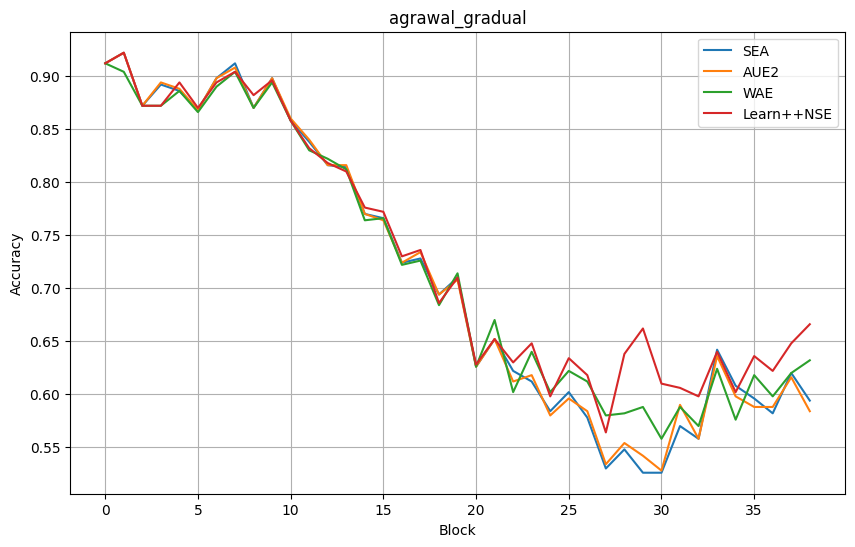

In [8]:
from IPython.display import Image, display
display(Image(filename="plots/agrawal_gradual.png"))

In [9]:
print("=== Recurrent Drift ===")
df_recurrent.style.background_gradient(cmap="Greens")

=== Recurrent Drift ===


,Model,Accuracy,Min Accuracy,Kappa,Diversity,Time (s),Recovery,Num Drops
3,Learn++NSE,0.686600,0.472000,0.393600,0.275500,10.958700,5.750000,4.000000
2,WAE,0.680600,0.498000,0.372000,0.272000,17.646600,5.750000,4.000000
1,AUE2,0.675200,0.476000,0.358900,0.269500,16.111300,5.500000,4.000000
0,SEA,0.670800,0.488000,0.348400,0.268800,12.861100,5.250000,4.000000


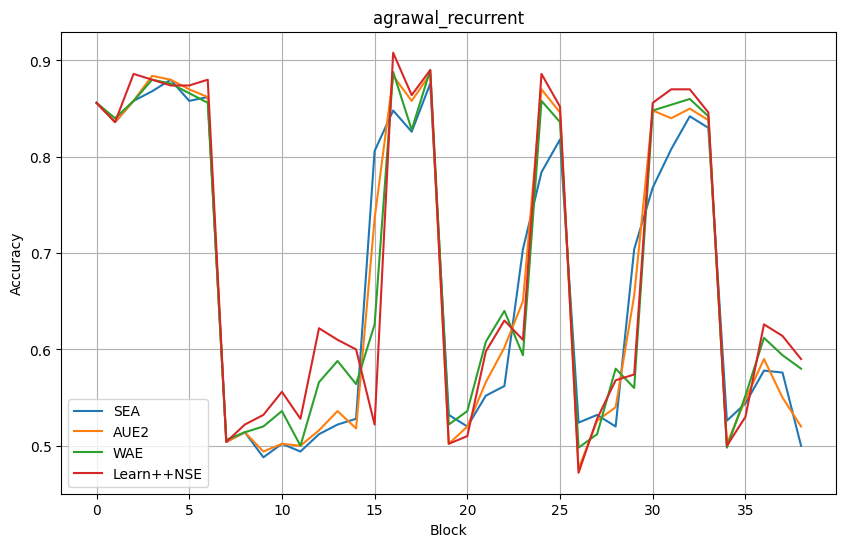

In [10]:

display(Image(filename="plots/agrawal_recurrent.png"))

In [11]:
print("=== Abrupt Drift ===")
df_abrupt.style.background_gradient(cmap="Blues")

=== Abrupt Drift ===


,Model,Accuracy,Min Accuracy,Kappa,Diversity,Time (s),Recovery,Num Drops
3,Learn++NSE,0.748300,0.466000,0.625300,0.183800,10.778500,20.000000,1.000000
2,WAE,0.732500,0.460000,0.603200,0.185900,17.641100,20.000000,1.000000
1,AUE2,0.722300,0.450000,0.603900,0.183300,16.034200,20.000000,1.000000
0,SEA,0.716900,0.458000,0.599400,0.183500,12.823900,20.000000,1.000000


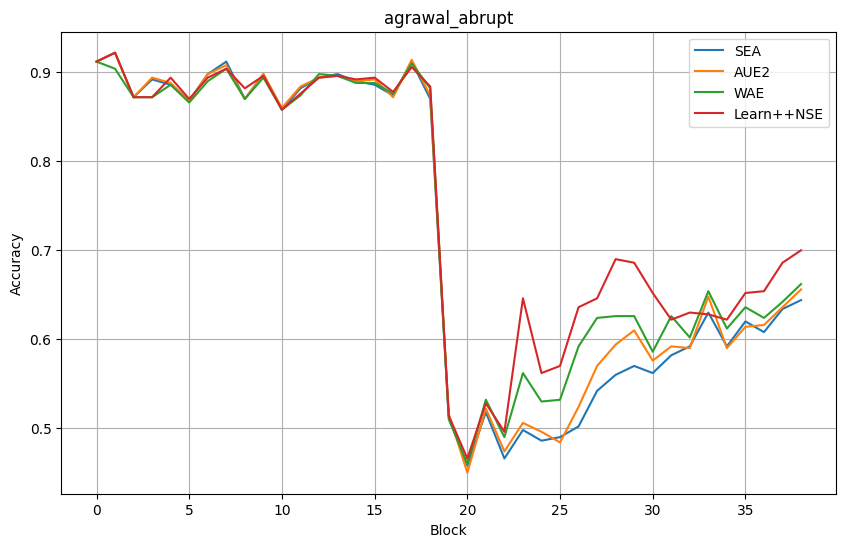

In [12]:

display(Image(filename="plots/agrawal_abrupt.png"))

In [ ]:
import src.optimization.moea_learnpp as moea_learnpp

moea_learnpp.main()

Dataset: datasets/agrawal_recurrent.csv
Número de bloques usados: 15
Evaluaciones máximas NSGA-II: 50
Objetivo de coste usa tiempo real: False
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       10 |      5 |             - |             -
     2 |       20 |      6 |  0.0792079208 |         ideal
     3 |       30 |      9 |  0.1512605042 |         ideal
     4 |       40 |     10 |  0.0625000000 |         ideal
     5 |       50 |     10 |  0.0625000000 |         ideal

=== Frente de Pareto encontrado ===
        a        b  max_size  accuracy  diversity   cost
0  0.4121   3.3320        21  0.674714   0.316492  294.0
1  1.5789   2.9772        16  0.672714   0.316492  224.0
2  0.6019   3.7575         6  0.670714   0.304843   84.0
3  0.5318   8.7642         7  0.664571   0.310733   98.0
4  0.5318   9.0693         7  0.664571   0.310733   98.0
5  1.5462  12.0049         8  0.664286   0.315165  112.0
6  1.3928  12.7208         8  0.664286   0.315165  112.0
7  0.4121 

In [2]:
import pandas as pd

df_pareto = pd.read_csv("pareto_learnpp.csv")
df_pareto

,a,b,max_size,accuracy,diversity,cost
0,0.4121,3.3320,21,0.674714,0.316492,294.0
1,1.5789,2.9772,16,0.672714,0.316492,224.0
2,0.6019,3.7575,6,0.670714,0.304843,84.0
3,0.5318,8.7642,7,0.664571,0.310733,98.0
4,0.5318,9.0693,7,0.664571,0.310733,98.0
5,1.5462,12.0049,8,0.664286,0.315165,112.0
6,1.3928,12.7208,8,0.664286,0.315165,112.0
7,0.4121,8.6382,5,0.663714,0.293519,70.0
8,1.2788,12.4308,15,0.657714,0.316492,210.0
9,1.2803,12.5187,15,0.657714,0.316492,210.0
